In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Downloads\Position_Salaries.csv")
x=dataset.iloc[:,1:-1].values
y=dataset.iloc[:,-1].values

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [15]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x,y)

LinearRegression()

In [83]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor=PolynomialFeatures(degree=4)
x_poly=poly_regressor.fit_transform(x)
regressor2=LinearRegression()
regressor2.fit(x_poly,y)

LinearRegression()

In [84]:
print(x_poly)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


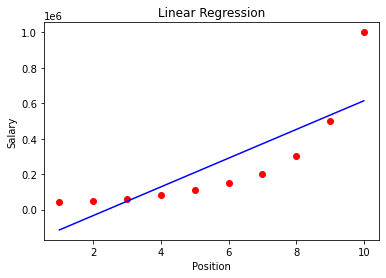

In [85]:
plt.scatter(x,y,color='red')
plt.plot(x,regressor.predict(x),color="blue")
plt.title("Linear Regression")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

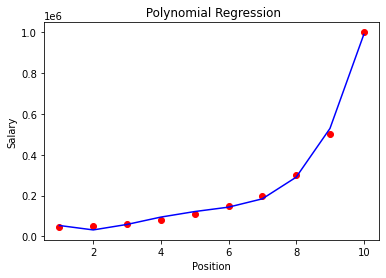

In [86]:
plt.scatter(x,y,color='red')
plt.plot(x,regressor2.predict(x_poly),color="blue")
plt.title(" Polynomial Regression")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

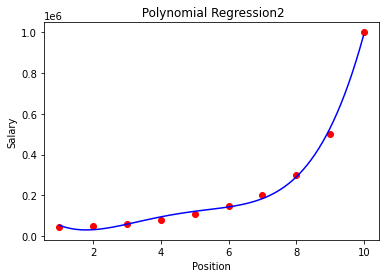

In [87]:
x_grid=np.arange(min(x),max(x),0.111)
x_grid=x_grid.reshape(len(x_grid),1)
plt.scatter(x,y,color='red')
plt.plot(x_grid,regressor2.predict(poly_regressor.fit_transform(x_grid)),color="blue")
plt.title(" Polynomial Regression2")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

In [88]:
x_grid=np.arange(min(x),max(x),0.1)
print(x_grid)

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1 6.2 6.3
 6.4 6.5 6.6 6.7 6.8 6.9 7.  7.1 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1
 8.2 8.3 8.4 8.5 8.6 8.7 8.8 8.9 9.  9.1 9.2 9.3 9.4 9.5 9.6 9.7 9.8 9.9]


In [89]:
regressor.predict([[6.5]])

array([330378.78787879])

In [90]:
regressor2.predict(poly_regressor.fit_transform([[6.5]]))

array([158862.45265155])

# Model Selection - R Square

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Desktop\Machine Learning A-Z (Codes and Datasets)\Model Selection\Regression\Data.csv")
x=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_regressor=PolynomialFeatures(degree=4)
x_poly=poly_regressor.fit_transform(x_train)
regressor=LinearRegression()
regressor.fit(x_poly,y_train)

LinearRegression()

In [5]:
y_pred=regressor.predict(poly_regressor.transform(x_test))
np.set_printoptions(precision=2) #number of decimals 
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[433.94 431.23]
 [457.9  460.01]
 [460.52 461.14]
 ...
 [469.53 473.26]
 [438.27 438.  ]
 [461.66 463.28]]


In [6]:
print(y_pred,y_test)

[433.94 457.9  460.52 ... 469.53 438.27 461.66] [431.23 460.01 461.14 ... 473.26 438.   463.28]


In [7]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.9425118639825149

In [8]:
print(y_test.shape,y_pred.shape)

(1914,) (1914,)
